# Breast Cancer Screening Inequalities in England
### A health-equity analysis, with a local focus on Hampshire & Isle of Wight

**Author: Marina Volkaert**  ·  Tools: Python (pandas, NumPy, matplotlib)

This notebook asks whether breast screening coverage falls as deprivation rises, whether the pattern holds locally in Hampshire & Isle of Wight, and which practices a public health team should target first.

*Data: OHID Fingertips (indicator 94063) · Health Equity Evidence Centre practice-level IMD · NHS ODS · NHS standard BSP-S02.*
*Coded in Python with AI support as a learning aid, while actively building my own coding fluency.*

---


## 1. Loaded and verified the data
Before any analysis, I checked the file is what it claims to be. The first columns (`Indicator ID`, `Indicator Name`) are the fingerprint - I checked that they read **94063, breast screening coverage**.


In [ ]:
import pandas as pd

screening = pd.read_csv('screening_94063.csv')
imd = pd.read_csv('imd_practice.csv')
screening.head(10)


,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
0,94063,Breast screening coverage: aged 53 to 70 years...,NaN,NaN,E92000001,England,England,Female,53-70 yrs,NaN,...,4305230,6460635,NaN,NaN,Not compared,Not compared,20220000,NaN,NaN,1y
1,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,290,440,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
2,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81002,Queens Park Medical Centre,GPs,Female,53-70 yrs,NaN,...,1765,2400,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
3,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81004,Acklam Medical Centre,GPs,Female,53-70 yrs,NaN,...,820,1150,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
4,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81005,Springwood Surgery,GPs,Female,53-70 yrs,NaN,...,825,1055,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
5,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81006,Tennant Street Medical Practice,GPs,Female,53-70 yrs,NaN,...,1175,1680,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
6,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81007,Bankhouse Surgery,GPs,Female,53-70 yrs,NaN,...,900,1225,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
7,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81009,Village Medical Centre,GPs,Female,53-70 yrs,NaN,...,690,1035,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
8,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81011,Chadwick Practice,GPs,Female,53-70 yrs,NaN,...,950,1475,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
9,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81012,Westbourne Medical Centre,GPs,Female,53-70 yrs,NaN,...,335,550,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y


I loaded the deprivation file too, so both tables are in memory and can be joined later. Keeping them in two separate names means both stay available.


In [ ]:
import pandas as pd

screening = pd.read_csv('screening_94063.csv')
imd = pd.read_csv('imd_practice.csv')
imd.head(10)

,Practice.Code,IMD,Year
0,A81001,25.075122,2010
1,A81001,25.888160,2011
2,A81001,26.701198,2012
3,A81001,27.514235,2013
4,A81001,28.327273,2014
5,A81001,29.140310,2015
6,A81001,29.945468,2016
7,A81001,30.750625,2017
8,A81001,31.555782,2018
9,A81001,32.360939,2019


## 2. Kept only GP practices
The file mixes several geography levels (England, ICBs, PCNs, GPs). The analysis is at practice level, so I filtered to the `GPs` rows only.


In [ ]:
gp = screening[ screening['Area Type'] == 'GPs' ]
gp.head(10)

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
1,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,290,440,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
2,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81002,Queens Park Medical Centre,GPs,Female,53-70 yrs,NaN,...,1765,2400,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
3,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81004,Acklam Medical Centre,GPs,Female,53-70 yrs,NaN,...,820,1150,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
4,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81005,Springwood Surgery,GPs,Female,53-70 yrs,NaN,...,825,1055,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
5,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81006,Tennant Street Medical Practice,GPs,Female,53-70 yrs,NaN,...,1175,1680,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
6,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81007,Bankhouse Surgery,GPs,Female,53-70 yrs,NaN,...,900,1225,NaN,NaN,Higher 99.8,Not compared,20220000,NaN,NaN,1y
7,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81009,Village Medical Centre,GPs,Female,53-70 yrs,NaN,...,690,1035,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
8,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81011,Chadwick Practice,GPs,Female,53-70 yrs,NaN,...,950,1475,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
9,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81012,Westbourne Medical Centre,GPs,Female,53-70 yrs,NaN,...,335,550,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
10,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81013,Brotton Surgery,GPs,Female,53-70 yrs,NaN,...,570,925,NaN,NaN,Lower 99.8,Not compared,20220000,NaN,NaN,1y


Verified the filter is clean - only `GPs` should remain.


In [ ]:
print(gp['Area Type'].unique())

['GPs']


Sanity-check the row count. About 18,800 is roughly **three times** the ~6,000 GP practices in England.


In [ ]:
len(gp)

18837

I investigated the root cause by drilling into a single practice to see why. Three rows per practice = **three years** (2022, 2023, 2024) stacked together. That explains the ×3.


In [ ]:
gp[ gp['Area Code'] == 'A81001' ]

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
1,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,290,440,NaN,NaN,Similar,Not compared,20220000,NaN,NaN,1y
7863,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,290,425,NaN,NaN,Similar,Not compared,20230000,NaN,NaN,1y
15572,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,310,430,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y


## 3. Choose one year
I kept 2024, the most current picture. Note: `Time period Sortable` is stored as a number, so the filter compares to `20240000` **without quotes** (quotes would make it text, and text never equals a number).


In [ ]:
data_2024 = gp[ gp['Time period Sortable'] == 20240000 ]
data_2024.head(10)

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range
15572,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81001,The Densham Surgery,GPs,Female,53-70 yrs,NaN,...,310,430,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15573,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81002,Queens Park Medical Centre,GPs,Female,53-70 yrs,NaN,...,1800,2425,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15574,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81004,Acklam Medical Centre,GPs,Female,53-70 yrs,NaN,...,885,1150,NaN,Cannot be calculated,Higher 99.8,Not compared,20240000,NaN,NaN,1y
15575,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81005,Springwood Surgery,GPs,Female,53-70 yrs,NaN,...,810,1025,NaN,Cannot be calculated,Higher 99.8,Not compared,20240000,NaN,NaN,1y
15576,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81006,Tennant Street Medical Practice,GPs,Female,53-70 yrs,NaN,...,1240,1710,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15577,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81007,Bankhouse Surgery,GPs,Female,53-70 yrs,NaN,...,890,1240,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15578,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81009,Village Medical Centre,GPs,Female,53-70 yrs,NaN,...,725,1020,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15579,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81011,Chadwick Practice,GPs,Female,53-70 yrs,NaN,...,1105,1520,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15580,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81012,Westbourne Medical Centre,GPs,Female,53-70 yrs,NaN,...,395,565,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y
15581,94063,Breast screening coverage: aged 53 to 70 years...,E92000001,England,A81013,Brotton Surgery,GPs,Female,53-70 yrs,NaN,...,730,1020,NaN,Cannot be calculated,Similar,Not compared,20240000,NaN,NaN,1y


In [ ]:
len(data_2024)

6173

## 4. Prepared the deprivation data
Filtered the IMD table to 2024 so it lines up with the screening year.


In [ ]:
imd_2024 = imd[ imd['Year'] == 2024 ]
imd_2024.head(10)

,Practice.Code,IMD,Year
14,A81001,32.360939,2024
30,A81002,31.921958,2024
46,A81003,41.387829,2024
62,A81004,28.024026,2024
78,A81005,15.398207,2024
94,A81006,35.612387,2024
110,A81007,34.444532,2024
126,A81008,51.551453,2024
142,A81009,35.865849,2024
158,A81011,36.308902,2024


In [ ]:
len(imd_2024)

8461

using modelled 2024 IMD from HEEC, chosen to align with 2024 screening; deprivation is stable over five years so this closely matches the real 2019 index.




## 5. Trimed to the columns the analysis needs
Kept the identifiers (code, name), the raw counts (`Count`, `Denominator`) so coverage can be rebuilt and trusted, the coverage `Value`, and the 95% confidence interval bounds.


In [ ]:
keep = ['Area Code', 'Area Name', 'Count', 'Denominator',
        'Value', 'Lower CI 95.0 limit', 'Upper CI 95.0 limit']

screening_clean = data_2024[keep]
screening_clean.head()

,Area Code,Area Name,Count,Denominator,Value,Lower CI 95.0 limit,Upper CI 95.0 limit
15572,A81001,The Densham Surgery,310,430,72.093023,67.672158,76.122642
15573,A81002,Queens Park Medical Centre,1800,2425,74.226804,72.448611,75.928363
15574,A81004,Acklam Medical Centre,885,1150,76.956522,74.435312,79.298240
15575,A81005,Springwood Surgery,810,1025,79.024390,76.425882,81.406158
15576,A81006,Tennant Street Medical Practice,1240,1710,72.514620,70.349935,74.578375


## 6. Joined screening to deprivation
Both tables share the practice code, so an **inner join** on it gives each practice both its coverage and its deprivation. Inner means only fully-matched practices survive.


In [ ]:
merged = screening_clean.merge(
    imd_2024,
    left_on='Area Code',
    right_on='Practice.Code',
    how='inner'
)
merged.head()

,Area Code,Area Name,Count,Denominator,Value,Lower CI 95.0 limit,Upper CI 95.0 limit,Practice.Code,IMD,Year
0,A81001,The Densham Surgery,310,430,72.093023,67.672158,76.122642,A81001,32.360939,2024
1,A81002,Queens Park Medical Centre,1800,2425,74.226804,72.448611,75.928363,A81002,31.921958,2024
2,A81004,Acklam Medical Centre,885,1150,76.956522,74.435312,79.298240,A81004,28.024026,2024
3,A81005,Springwood Surgery,810,1025,79.024390,76.425882,81.406158,A81005,15.398207,2024
4,A81006,Tennant Street Medical Practice,1240,1710,72.514620,70.349935,74.578375,A81006,35.612387,2024


In [ ]:
len(merged)

6157

16 practices, 0.3 percent, did not match to deprivation data and were excluded.



**Why inner, not left:** a left join keeps every screening practice even when deprivation is missing, leaving blanks that can't sit on a gradient. The cells below demonstrate that difference — the unmatched rows are mostly placeholder/closed practices, so dropping them is a bonus, not a loss. The analysis uses the inner join.


In [ ]:
merged = screening_clean.merge(
    imd_2024,
    left_on='Area Code',
    right_on='Practice.Code',
    how='left'
)
merged.head()

,Area Code,Area Name,Count,Denominator,Value,Lower CI 95.0 limit,Upper CI 95.0 limit,Practice.Code,IMD,Year
0,A81001,The Densham Surgery,310,430,72.093023,67.672158,76.122642,A81001,32.360939,2024.0
1,A81002,Queens Park Medical Centre,1800,2425,74.226804,72.448611,75.928363,A81002,31.921958,2024.0
2,A81004,Acklam Medical Centre,885,1150,76.956522,74.435312,79.298240,A81004,28.024026,2024.0
3,A81005,Springwood Surgery,810,1025,79.024390,76.425882,81.406158,A81005,15.398207,2024.0
4,A81006,Tennant Street Medical Practice,1240,1710,72.514620,70.349935,74.578375,A81006,35.612387,2024.0


In [ ]:
merged[ merged['IMD'].isna() ]

,Area Code,Area Name,Count,Denominator,Value,Lower CI 95.0 limit,Upper CI 95.0 limit,Practice.Code,IMD,Year
6157,Y06345,Bromleag Care Practice,15,50,30.000000,19.103554,43.750350,NaN,NaN,NaN
6158,Y06356,Bilborough Medical Centre,595,955,62.303665,59.186501,65.322243,NaN,NaN,NaN
6159,Y06378,Heath Street Health Centre,130,290,44.827586,39.208564,50.581849,NaN,NaN,NaN
6160,Y06443,Whyburn Medical Practice,1005,1400,71.785714,69.371149,74.081051,NaN,NaN,NaN
6161,Y06659,Nook Surgery,205,365,56.164384,51.036025,61.164339,NaN,NaN,NaN
6162,Y06792,Broad Oak Medical Practice,320,555,57.657658,53.508117,61.701921,NaN,NaN,NaN
6163,Y06810,Whitehouse Health Centre,640,960,66.666667,63.623457,69.577024,NaN,NaN,NaN
6164,Y07014,Shakespeare Road Medical Practice,745,1150,64.782609,61.976931,67.489856,NaN,NaN,NaN
6165,Y07020,placeholder,10,45,22.222222,12.544686,36.269292,NaN,NaN,NaN
6166,Y07025,Park Medical Centre,580,850,68.235294,65.029431,71.277075,NaN,NaN,NaN


## 7. Grouped practices by deprivation (national)
`qcut` splits practices into five **equal-sized** groups by deprivation rank (not equal score-width). Group 1 = least deprived, group 5 = most deprived. A higher IMD score means more deprived.


In [ ]:
merged['imd_group'] = pd.qcut(merged['IMD'], 5, labels=[1, 2, 3, 4, 5])
merged[['Area Name', 'IMD', 'imd_group']].head(10)

,Area Name,IMD,imd_group
0,The Densham Surgery,32.360939,4
1,Queens Park Medical Centre,31.921958,4
2,Acklam Medical Centre,28.024026,4
3,Springwood Surgery,15.398207,2
4,Tennant Street Medical Practice,35.612387,5
5,Bankhouse Surgery,34.444532,5
6,Village Medical Centre,35.865849,5
7,Chadwick Practice,36.308902,5
8,Westbourne Medical Centre,52.647021,5
9,Brotton Surgery,29.722753,4


## 8. The key measure — coverage per deprivation group
Coverage is pooled by **number of women** (sum screened ÷ sum eligible), not averaged across practices. This counts every woman equally rather than letting a tiny practice weigh as much as a huge one.


In [ ]:
gradient = merged.groupby('imd_group').apply(
    lambda g: 100 * g['Count'].sum() / g['Denominator'].sum()
)
print(gradient)

imd_group
1    77.137987
2    75.038096
3    72.411942
4    68.475390
5    64.137404
dtype: float64


/tmp/ipykernel_4265/3001456657.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gradient = merged.groupby('imd_group').apply(
/tmp/ipykernel_4265/3001456657.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gradient = merged.groupby('imd_group').apply(


Confirmed the direction: as the deprivation score rises across groups, coverage falls. That **opposite movement** is the inequality.


In [ ]:
check = merged.groupby('imd_group').agg(
    avg_imd_score = ('IMD', 'mean'),
    women_screened = ('Count', 'sum'),
    women_eligible = ('Denominator', 'sum')
)
check['coverage'] = 100 * check['women_screened'] / check['women_eligible']
print(check[['avg_imd_score', 'coverage']])

           avg_imd_score   coverage
imd_group                          
1               9.785444  77.137987
2              15.316639  75.038096
3              21.355135  72.411942
4              28.528210  68.475390
5              41.614969  64.137404


/tmp/ipykernel_4265/3778950641.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = merged.groupby('imd_group').agg(


## 9. Is the gap real, or chance?
95% confidence intervals around each group. Because each group pools hundreds of thousands of women, the intervals are tiny (~0.1%) and don't overlap — so the gradient is **statistically real**, not noise.


In [ ]:
import numpy as np

grp = merged.groupby('imd_group').agg(
    screened = ('Count', 'sum'),
    eligible = ('Denominator', 'sum')
)

grp['coverage'] = 100 * grp['screened'] / grp['eligible']

# standard error of a proportion, then the 95% interval
p = grp['screened'] / grp['eligible']
se = np.sqrt(p * (1 - p) / grp['eligible'])
grp['ci_low']  = 100 * (p - 1.96 * se)
grp['ci_high'] = 100 * (p + 1.96 * se)

print(grp[['coverage', 'ci_low', 'ci_high']].round(2))

           coverage  ci_low  ci_high
imd_group                           
1             77.14   77.07    77.20
2             75.04   74.97    75.11
3             72.41   72.34    72.49
4             68.48   68.39    68.56
5             64.14   64.04    64.23


/tmp/ipykernel_4265/3168121069.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = merged.groupby('imd_group').agg(


## 10. Visualised the national gradient
A line chart suits an ordered trend. The axis starts near the data (honest for a line chart, and clearly labelled) so the real gap is visible without exaggeration.


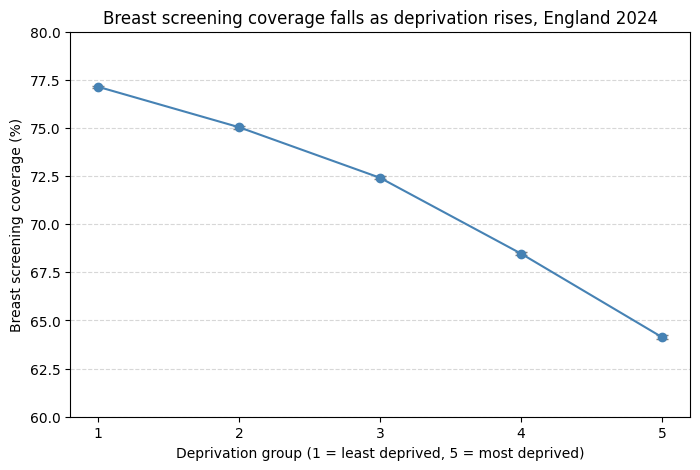

In [ ]:
import matplotlib.pyplot as plt

groups = grp.index.astype(str)          # '1' to '5'
coverage = grp['coverage']

# turn the CI bounds into distances from the point, which is what matplotlib wants
lower_error = coverage - grp['ci_low']
upper_error = grp['ci_high'] - coverage
errors = [lower_error, upper_error]

plt.figure(figsize=(8, 5))

# the line with a marker at each group, plus the confidence interval whiskers
plt.errorbar(groups, coverage,
             yerr=errors,
             fmt='-o', color='steelblue',
             capsize=4, ecolor='grey')

plt.ylim(60, 80)                        # start near the data, honest because it is labelled
plt.xlabel('Deprivation group (1 = least deprived, 5 = most deprived)')
plt.ylabel('Breast screening coverage (%)')
plt.title('Breast screening coverage falls as deprivation rises, England 2024')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 11. Narrowed to Hampshire & Isle of Wight
The screening file has no local label, so I used the official NHS ODS list of Hampshire & IoW practices as a **membership test** (`isin`) to keep only local practices. Closed practices in the ODS list simply don't match 2024 data, so they drop out harmlessly.


In [ ]:
ods = pd.read_excel('/content/ODS Advanced Search (Include headers).xlsx')

hants_codes = ods['Code']              # the list of Hampshire & IoW practice codes

local = merged[ merged['Area Code'].isin(hants_codes) ]
len(local)

143

What a public Health team would want to focus in the scale of Hampshire and the IoW is where the deprivation is high (IMD_group= 5 at national scale) and where there is a low screening coverage that does not meet the NHS Breast Screening Programme screening standards, **standard BSP-S02 Coverage**, GOV.UK of below the 70 percent NHS acceptable standard.

Source: https://www.gov.uk/government/publications/breast-screening-consolidated-programme-standards/nhs-breast-screening-programme-screening-standards-valid-for-data-collected-from-1-april-2021

Using the **national** deprivation groups, only 3 local practices fall in group 5 and below the 70% standard — because Hampshire is relatively affluent, so few practices are deprived by national standards.


In [ ]:
targets = local[ (local['imd_group'] == 5) & (local['Value'] < 70) ]
targets

,Area Code,Area Name,Count,Denominator,Value,Lower CI 95.0 limit,Upper CI 95.0 limit,Practice.Code,IMD,Year,imd_group
3528,J82024,Solent GP Surgery,660,1135,58.149780,55.257060,60.987519,J82024,33.774996,2024.0,5
3567,J82085,Island City Practice,2185,3325,65.714286,64.083593,67.308710,J82085,37.470743,2024.0,5
3629,J82213,Brook House Surgery,370,540,68.518519,64.482117,72.293307,J82213,33.732434,2024.0,5


Only 3 GP practices returned, therefore it was looking like Hampshire barely has a deprivation problem, when it does, just at a scale that national grouping flattens.

Doing local analysis ranked Hampshire's practices only against each other. Now group 5 means "the most deprived fifth within Hampshire," even if those practices are only mid-table nationally. This answered the question a Hampshire public health team could asks: "within our own patch, where are our worst-served, most deprived communities." That is far more actionable for them. So I choose to present both to have the national view for context and comparability, and the local view for local action.

## 12. Re-ranked deprivation *within* Hampshire
A local team cares about their own most-deprived areas. Re-cutting deprivation among Hampshire practices only means `local_imd_group` 5 = the most deprived fifth **within Hampshire**, even if mid-table nationally. Kept in a separate column so the national grouping is preserved.


In [ ]:
local = local.copy()   # avoids a pandas warning when adding a column to a slice
local['local_imd_group'] = pd.qcut(local['IMD'], 5, labels=[1, 2, 3, 4, 5])
local[['Area Name', 'IMD', 'imd_group', 'local_imd_group']].head(10)

,Area Name,IMD,imd_group,local_imd_group
3513,Burgess Road Surgery,23.525755,3,4
3514,Lordshill Health Centre,27.567593,4,5
3515,Rowlands Castle Surgery,11.552091,1,2
3516,Coastal Medical Partnership,14.941580,2,3
3517,Emsworth Surgery,12.058738,1,2
3518,The Bosmere Medical Practice,26.789735,4,5
3519,Portchester Practice,13.007569,2,3
3520,Giffard Drive Surgery,14.291360,2,3
3521,Stockbridge Surgery,11.986456,1,2
3522,The andover Health Centre Medical Pract,12.261524,1,2


The local gradient — the same pattern appears, narrower than nationally (an affluent area).


In [ ]:
gradient = local.groupby('local_imd_group').apply(
    lambda g: 100 * g['Count'].sum() / g['Denominator'].sum()
)
print(gradient)

local_imd_group
1    80.342298
2    80.980225
3    77.627082
4    75.249660
5    72.729041
dtype: float64


/tmp/ipykernel_4265/2764889233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gradient = local.groupby('local_imd_group').apply(
/tmp/ipykernel_4265/2764889233.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gradient = local.groupby('local_imd_group').apply(


Local confidence intervals — wider than national (smaller groups), but the drops from group 2 downward don't overlap, so they are real. The top two groups overlap, so they are effectively tied.


In [ ]:
import numpy as np

grp = local.groupby('local_imd_group').agg(
    screened = ('Count', 'sum'),
    eligible = ('Denominator', 'sum')
)

grp['coverage'] = 100 * grp['screened'] / grp['eligible']

# standard error of a proportion, then the 95% interval
p = grp['screened'] / grp['eligible']
se = np.sqrt(p * (1 - p) / grp['eligible'])
grp['ci_low']  = 100 * (p - 1.96 * se)
grp['ci_high'] = 100 * (p + 1.96 * se)

print(grp[['coverage', 'ci_low', 'ci_high']].round(2))

                 coverage  ci_low  ci_high
local_imd_group                           
1                   80.34   80.00    80.69
2                   80.98   80.63    81.33
3                   77.63   77.25    78.00
4                   75.25   74.85    75.65
5                   72.73   72.34    73.11


/tmp/ipykernel_4265/1739200413.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = local.groupby('local_imd_group').agg(


Within Hampshire, coverage is essentially level across the two least deprived groups, then falls steadily and significantly as deprivation rises through the middle and most deprived groups. The inequality pattern holds locally, and the drops that matter are real.

## 13. Visualised the local gradient
With the NHS 70% acceptable standard (BSP-S02) marked. I noted that every group *average* sits above 70% — yet that was hiding individual practices below it.


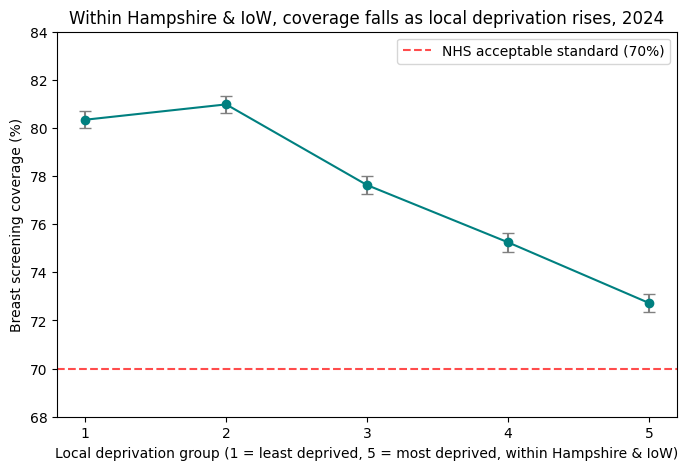

In [ ]:
import matplotlib.pyplot as plt

groups = grp.index.astype(str)
coverage = grp['coverage']

lower_error = coverage - grp['ci_low']
upper_error = grp['ci_high'] - coverage
errors = [lower_error, upper_error]

plt.figure(figsize=(8, 5))
plt.errorbar(groups, coverage, yerr=errors,
             fmt='-o', color='teal', capsize=4, ecolor='grey')

plt.axhline(70, color='red', linestyle='--', alpha=0.7, label='NHS acceptable standard (70%)')
plt.ylim(68, 84)
plt.xlabel('Local deprivation group (1 = least deprived, 5 = most deprived, within Hampshire & IoW)')
plt.ylabel('Breast screening coverage (%)')
plt.title('Within Hampshire & IoW, coverage falls as local deprivation rises, 2024')
plt.legend()
plt.show()

## 14. Identified the priority practices
The most-deprived local group, ranked by coverage. Ten practices fall below the 70% NHS standard — the ones a group average conceals.


In [ ]:
# --- Local group 5: Hampshire & IoW's most deprived practices, ranked by coverage ---

# 1. Keep only the most deprived local group, sorted worst coverage first
local_group5 = local[ local['local_imd_group'] == 5 ].sort_values('Value')

# 2. How many of them fall below the NHS 70% acceptable standard
below_70 = local_group5[ local_group5['Value'] < 70 ]
print("Practices in local group 5:", len(local_group5))
print("Of those, below the 70% standard:", len(below_70))
print()

# 3. Show the ranked list with the columns that matter
local_group5[['Area Code', 'Area Name', 'Count', 'Denominator', 'Value', 'IMD']]

Practices in local group 5: 29
Of those, below the 70% standard: 10



,Area Code,Area Name,Count,Denominator,Value,IMD
3528,J82024,Solent GP Surgery,660,1135,58.149780,33.774996
3568,J82087,Stoneham Lane Surgery,505,810,62.345679,26.473109
3582,J82115,Atherley House Surgery,290,455,63.736264,27.613426
3611,J82155,Portsdown Group Practice,3805,5840,65.154110,30.259379
3567,J82085,Island City Practice,2185,3325,65.714286,37.470743
3563,J82081,St Mary's Surgery,1120,1670,67.065868,29.261515
3642,J82669,Rowner Health Centre,615,915,67.213115,26.404217
3627,J82208,St Peter's Surgery,455,675,67.407407,27.543696
3629,J82213,Brook House Surgery,370,540,68.518519,33.732434
3624,J82199,The Unicity Medical Centre,300,430,69.767442,29.595954


## 15. Prioritised by impact
Added the number of women **not screened** (scale) alongside coverage (severity). Ranking by women missed points effort where it reaches the most people — large deprived practices like Portsdown and Island City.


In [ ]:
# Work on a clean copy of the 10 below-standard, most-deprived-locally practices
priority = local[ (local['local_imd_group'] == 5) & (local['Value'] < 70) ].copy()

# Impact metric 1: women eligible but not screened
priority['unscreened'] = priority['Denominator'] - priority['Count']

# Impact metric 2: how many more women must be screened just to reach the 70% standard
priority['shortfall_to_70'] = (priority['Denominator'] * 0.70 - priority['Count']).round().astype(int)

# Rank by the most women missed (impact first, as you decided)
priority = priority.sort_values('unscreened', ascending=False)

priority[['Area Code', 'Area Name', 'Value', 'Denominator', 'unscreened', 'shortfall_to_70']]

,Area Code,Area Name,Value,Denominator,unscreened,shortfall_to_70
3611,J82155,Portsdown Group Practice,65.154110,5840,2035,283
3567,J82085,Island City Practice,65.714286,3325,1140,142
3563,J82081,St Mary's Surgery,67.065868,1670,550,49
3528,J82024,Solent GP Surgery,58.149780,1135,475,134
3568,J82087,Stoneham Lane Surgery,62.345679,810,305,62
3642,J82669,Rowner Health Centre,67.213115,915,300,26
3627,J82208,St Peter's Surgery,67.407407,675,220,17
3629,J82213,Brook House Surgery,68.518519,540,170,8
3582,J82115,Atherley House Surgery,63.736264,455,165,28
3624,J82199,The Unicity Medical Centre,69.767442,430,130,1


---
## Findings & recommendation

**National:** coverage falls steadily from 77.1% (least deprived fifth) to 64.1% (most deprived) — a 13-point gap, confirmed real by non-overlapping confidence intervals.

**Local (Hampshire & IoW):** the same gradient holds, narrower (~8 points). Group averages stay above the 70% standard, but 10 individual practices fall below it.


**Where to act first:** ranked by women not screened — Portsdown Group Practice (2,035), Island City Practice (1,140), St Mary's Surgery (~550), Solent GP Surgery (lowest rate, 58.1%). Lifting the top four to 70% would screen ~600 more women.


**Recommended actions** (matched to barriers in the literature, not inferred from this data): mobile screening units at the largest priority practices; extended-hours appointments; community outreach and reminders; address-data cleaning at high-churn practices.

## Limitations & ethics
- Coverage is a 3-year measure, so it lags recent change.
- Deprivation is modelled at practice level and describes **areas, not individuals** (ecological fallacy) — not a claim about any single woman.
- 16 practices (0.3%) were excluded for missing data; some small-number figures are suppressed at source.
- All data is open and aggregate — no patient-level data used.

*Sources: NHS BSP-S02 standard (GOV.UK) · OHID Fingertips indicator 94063 · Health Equity Evidence Centre practice-level IMD · Cancer Research UK (supporting access to breast screening).*
